In [1]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO
from sklearn.metrics import mean_squared_error

import pandas as pd
import numpy.matlib as matlib
import scipy.signal

from phaseEM import *
from extract_features import *
from channel_evaluation import *
import config as cfg
from reconstruction_minimal import *
from notebookfunctions import *

feat_path = r'./features'
result_path = r'./results'


%load_ext autoreload
%autoreload 2

import importlib
importlib.reload(phaseEM)

winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5
sr=1024
path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'
path_somata = '/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/somata'

nr of frequencies in somata results in total: 481


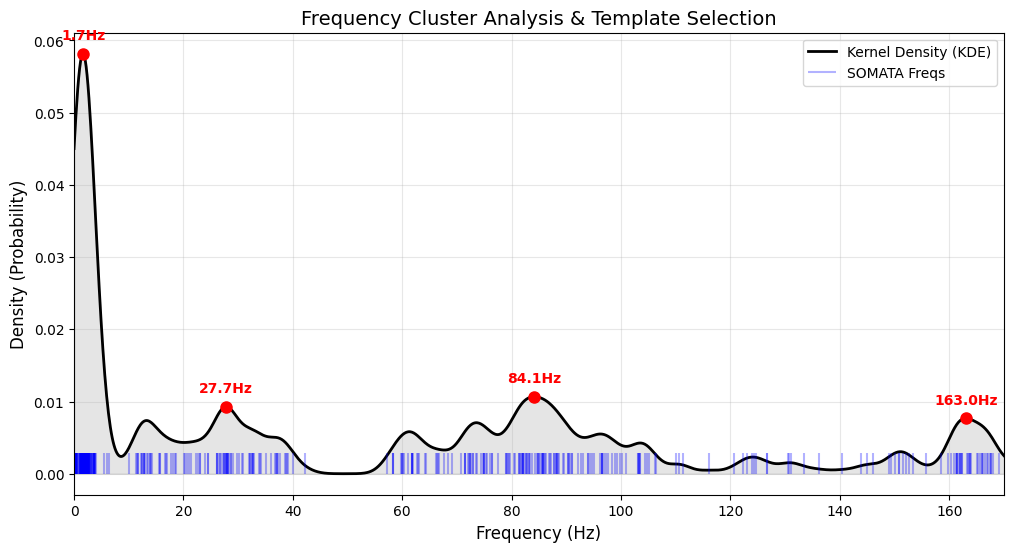

In [2]:

participant = 'sub-07'
initParams_list = get_initParams(participant)
initParams = initParams_list[0]

In [2]:

def analyze_parameter_evolution(init_params, n_chunks=5, t_segment=4, start = 0):
    evolution = []

    for i in range(n_chunks):
        eeg = get_eeg(participant, t_start = start + t_segment*i, t_segment=t_segment)
        test_data = eeg[:,0]

        # Run EM on this specific segment
        _, _, params = causalPhaseEM_MKmdl_noSeg(test_data, initParams, flagNoFit=False)
        
        if params:
            evolution.append({
                "chunk": i,
                "timestamp": (t_segment*i),
                "freqs": params["freqs"],
                "ampVec": params["ampVec"],
                "sigmaFreqs": params["sigmaFreqs"],
                "sigmaObs": params["sigmaObs"] if np.isscalar(params["sigmaObs"]) else params["sigmaObs"].flatten()[0]
            })
    return evolution

def plot_parameter_evolution(history, init_params):
    times = [h['timestamp'] for h in history]
    n_osc = len(init_params['freqs'])
    
    fig, ax = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    
    # Frequency trajectories
    for i in range(n_osc):
        f_vals = [h['freqs'][i] for h in history]
        line, = ax[0].plot(times, f_vals, 'o-', label=f'Osc {i} (Init: {init_params["freqs"][i]:.1f}Hz)')
        # Draw a horizontal dashed line for the initial guess
        ax[0].axhline(y=init_params['freqs'][i], color=line.get_color(), linestyle='--', alpha=0.3)
    
    ax[0].set_ylabel("Frequency (Hz)")
    ax[0].set_title("Frequency Evolution (Solid=Fitted, Dashed=Initial)")
    ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax[0].grid(True, alpha=0.2)

    # Amplitude trajectories
    for i in range(n_osc):
        a_vals = [h['ampVec'][i] for h in history]
        line, = ax[1].plot(times, a_vals, 's-', label=f'Osc {i} (Init: {init_params["ampVec"][i]:.4f})')
        ax[1].axhline(y=init_params['ampVec'][i], color=line.get_color(), linestyle='--', alpha=0.3)
    
    ax[1].set_ylabel("Amplitude (Estimated)")
    ax[1].set_title("Oscillator Amplitude (Damping) Evolution")
    ax[1].grid(True, alpha=0.2)

    # observation noise (R)
    r_vals = [h['sigmaObs'] for h in history]
    ax[2].plot(times, r_vals, 'kD-', linewidth=2)
    ax[2].set_ylabel("Variance (R)")
    ax[2].set_xlabel("Time (s)")
    ax[2].set_title(f'Observation Noise (R) Trajectory (init: {init_params["sigmaObs"]})')
    ax[2].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

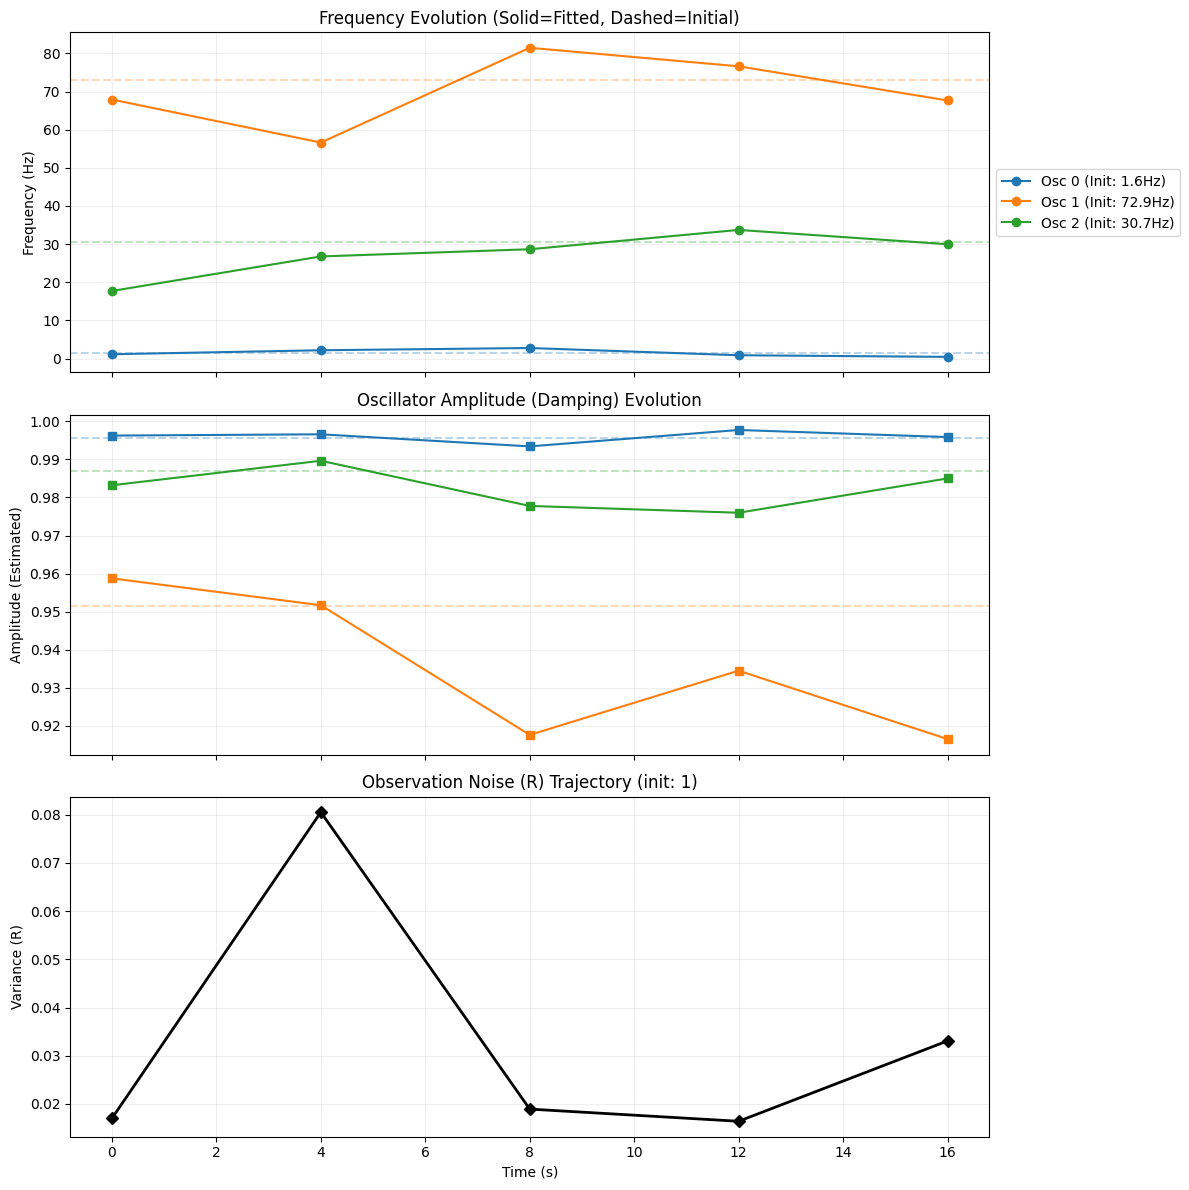

In [4]:
# run the plot
history = analyze_parameter_evolution(initParams_list[0], n_chunks=5, t_segment=4)
plot_parameter_evolution(history, initParams_list[0])

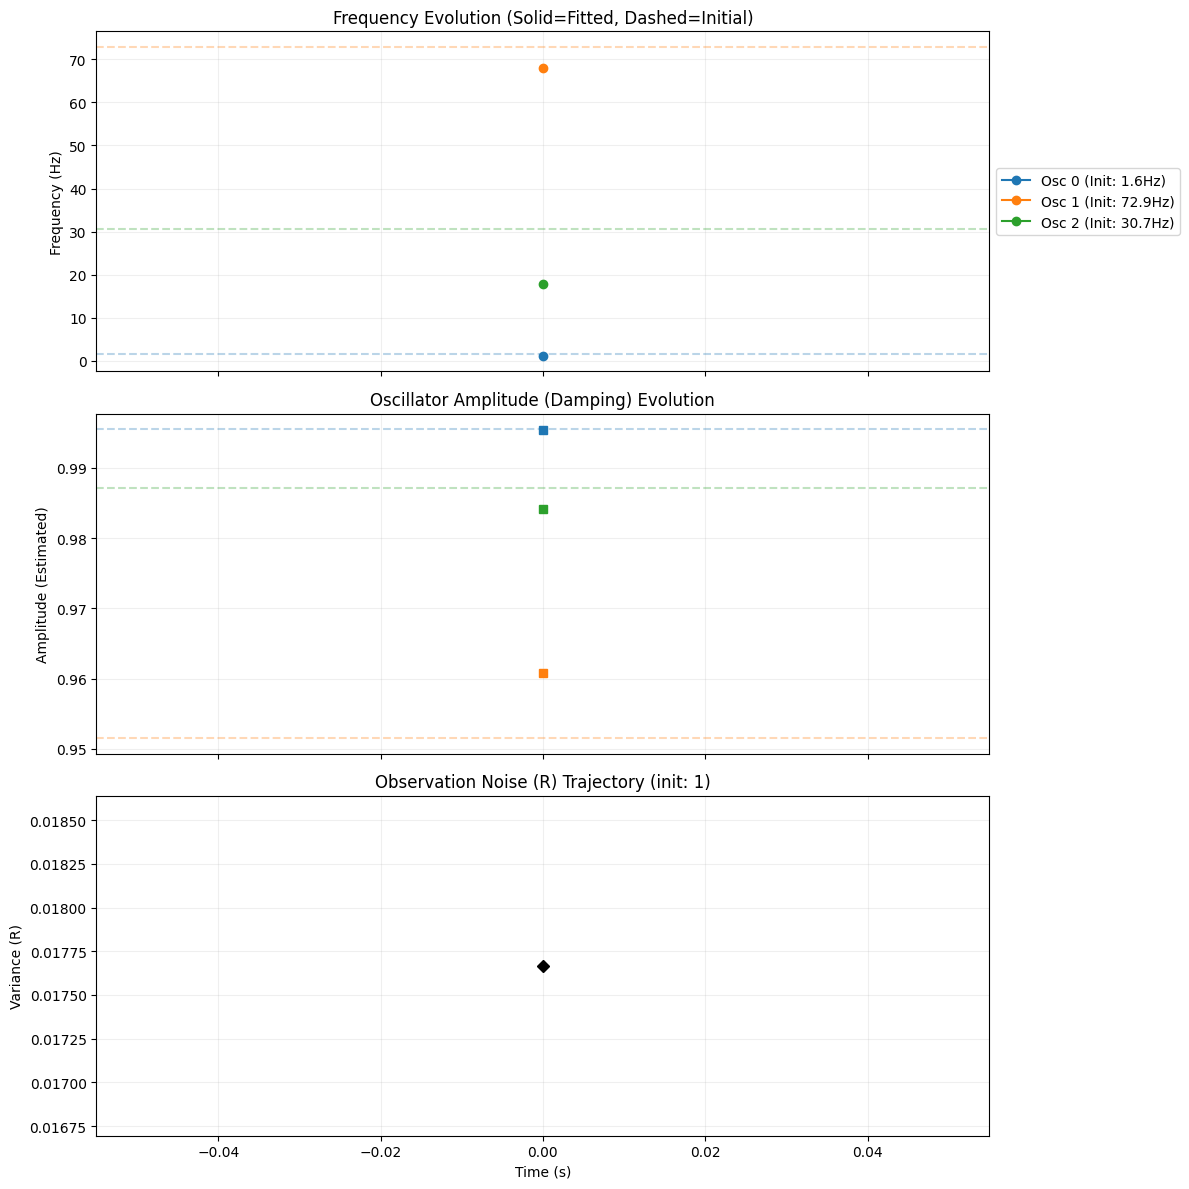

In [5]:
history = analyze_parameter_evolution(initParams_list[0], n_chunks=1, t_segment=5)
plot_parameter_evolution(history, initParams_list[0])

In [ ]:
participant = 'sub-08'
initParams_list = get_initParams(participant)
initParams = initParams_list[0]

history = analyze_parameter_evolution(initParams_list[0], n_chunks=1, t_segment=4)
plot_parameter_evolution(history, initParams_list[0])

In [3]:
#Now instead of giving the same initParams for each chunk, what if we plot how the EM would adapt the params throughout the signal?
#outcome: it is exactly the same
def analyze_progressed_evolution(init_params, n_chunks=5, t_segment=4, start = 0):
    evolution = []

    params = init_params #!
    for i in range(n_chunks):
        eeg = get_eeg(participant, t_start = start + t_segment*i, t_segment=t_segment)
        test_data = eeg[:,0]

        _, _, params = causalPhaseEM_MKmdl_noSeg(test_data, initParams, flagNoFit=False)
        
        if params:
            evolution.append({
                "chunk": i,
                "timestamp": (t_segment*i),
                "freqs": params["freqs"],
                "ampVec": params["ampVec"],
                "sigmaFreqs": params["sigmaFreqs"],
                "sigmaObs": params["sigmaObs"] if np.isscalar(params["sigmaObs"]) else params["sigmaObs"].flatten()[0]
            })
    return evolution

nr of frequencies in somata results in total: 481


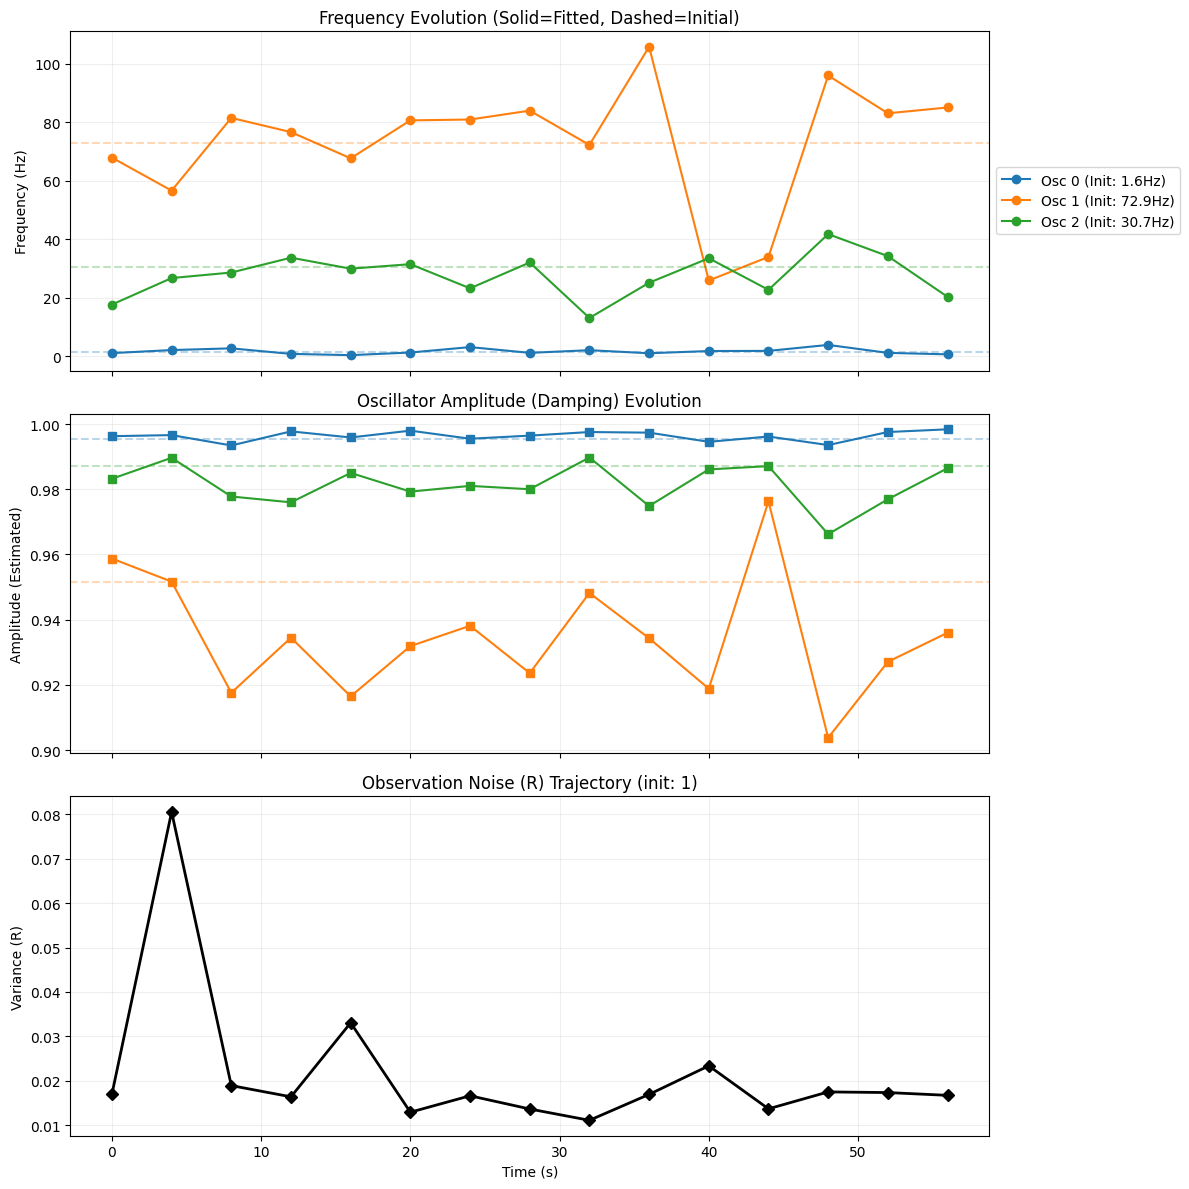

In [5]:
participant = 'sub-07'
initParams_list = get_initParams(participant)
initParams = initParams_list[0]

history = analyze_progressed_evolution(initParams_list[0], n_chunks=15, t_segment=4)
plot_parameter_evolution(history, initParams_list[0])

nr of frequencies in somata results in total: 174


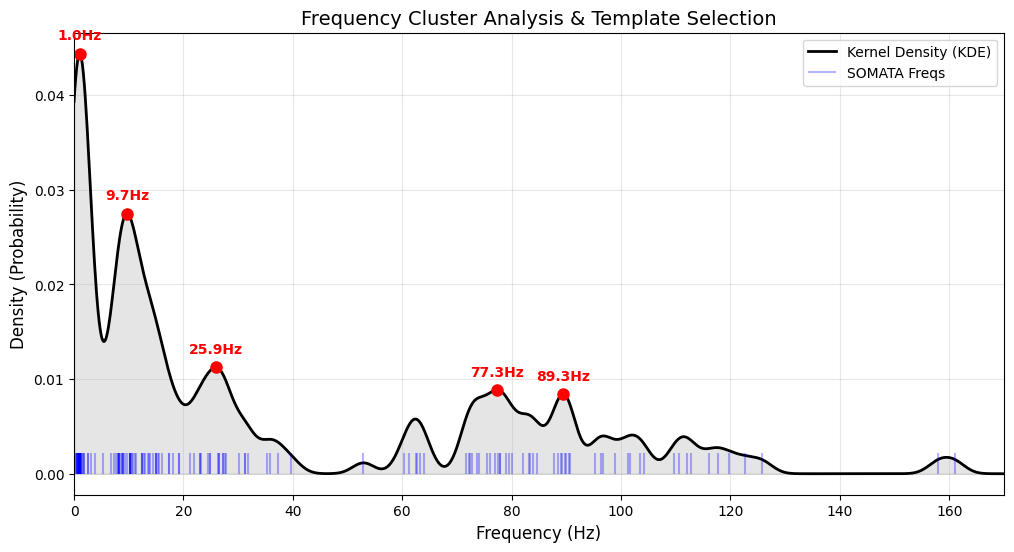

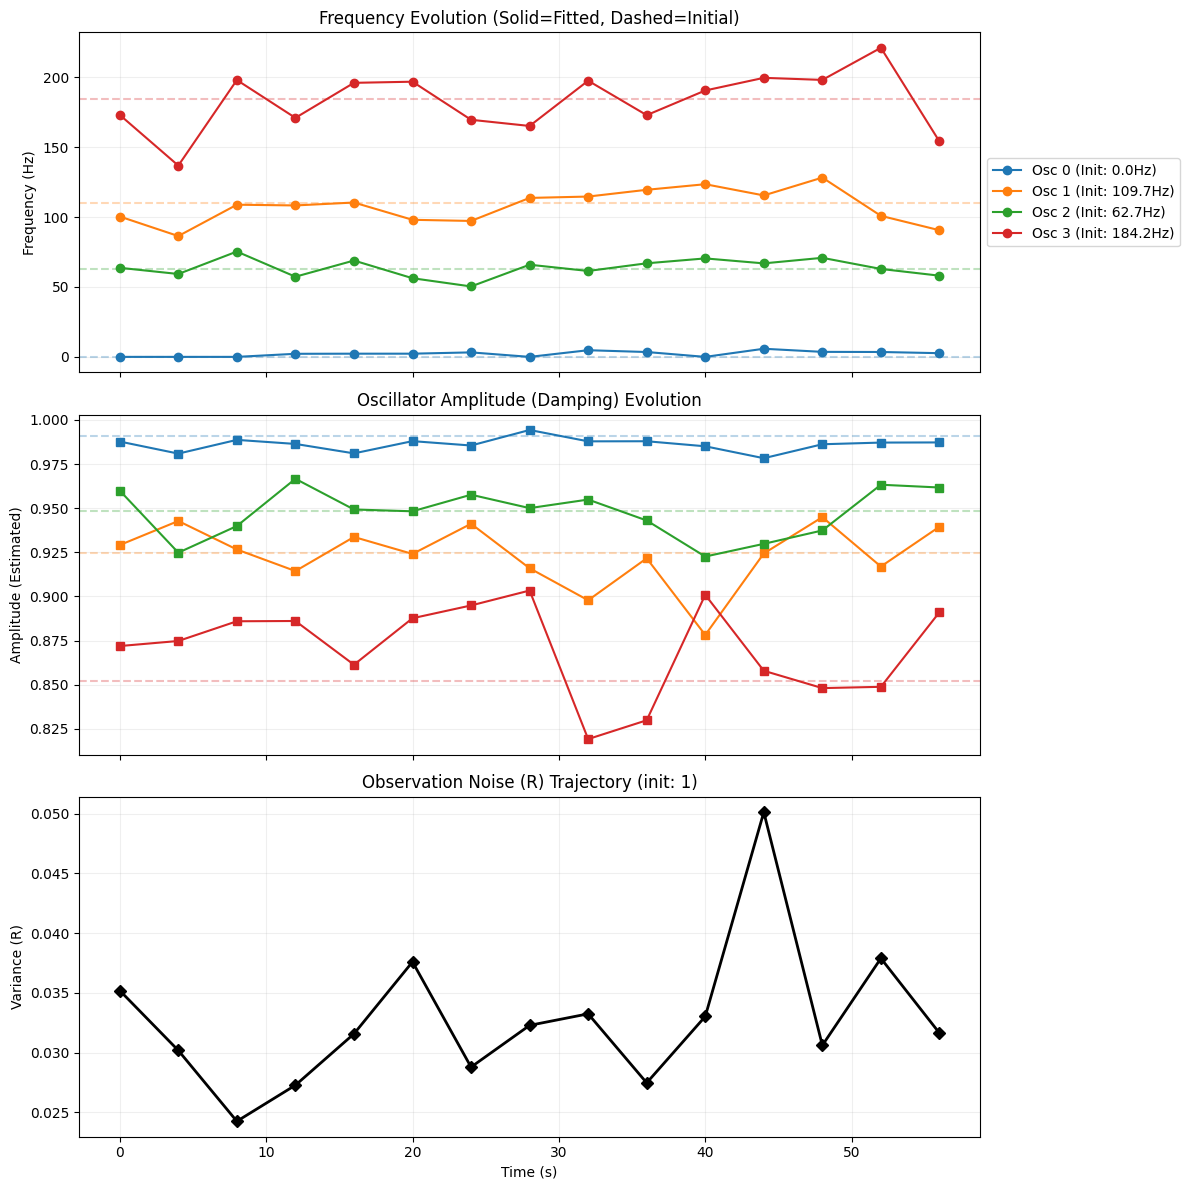

In [9]:
participant = 'sub-08'
initParams_list = get_initParams(participant)
initParams = initParams_list[0]

history = analyze_progressed_evolution(initParams_list[0], n_chunks=15, t_segment=4)
plot_parameter_evolution(history, initParams_list[0])

In [12]:
#what if we only give hg oscillator data to decoder?

feat_path = r'./features'
for pt in ['sub-08', 'sub-09', 'sub-10']:

    initParams_list = get_initParams(pt)
    all_feat = np.load(os.path.join(feat_path,f'{pt}_unstacked_SSPEfeat.npy'))
    
    hg_feat_indices = []
    current_pointer = 0
    
    for ch_idx, params in enumerate(initParams_list):
        freqs = np.array(params["freqs"])
        
        # Find which oscillators in this specific channel are in the HG range
        # Note: Using >= 70 and <= 170 to match your get_initParams logic
        is_hg = (freqs >= 30) & (freqs <= 170)
        
        # Get the global indices for these HG oscillators
        # if channel 0 has 5 osc, and osc 3 & 4 are HG, indices are [3, 4]
        # if channel 1 has 3 osc, and osc 1 is HG, indices are [5+1] = [6]
        ch_hg_indices = np.where(is_hg)[0] + current_pointer
        hg_feat_indices.extend(ch_hg_indices)
        
        # Move pointer by the total number of oscillators in this channel
        current_pointer += len(freqs)
    
    # Select only the HG columns from the features
    hg_only_feat = all_feat[:, hg_feat_indices]
    
    print(f"Original feature shape: {all_feat.shape}, nr_osc={current_pointer}")
    print(f"HG-only feature shape:  {hg_only_feat.shape}")
    
    hg_only_feat = stackFeatures(hg_only_feat)
    print(f"HG-only stacked feature shape:  {hg_only_feat.shape}")

    reconstruct([pt], SSPEfeatures=False, hg_osc_sspe_features=True, data=hg_only_feat)

nr of frequencies in somata results in total: 174
Original feature shape: (30032, 221), nr_osc=221
HG-only feature shape:  (30032, 63)
HG-only stacked feature shape:  (29992, 567)
sub-08 has mean correlation of 0.588065
nr of frequencies in somata results in total: 304
Original feature shape: (30033, 489), nr_osc=489
HG-only feature shape:  (30033, 79)
HG-only stacked feature shape:  (29993, 711)
sub-09 has mean correlation of 0.615503
nr of frequencies in somata results in total: 346
Original feature shape: (28500, 511), nr_osc=511
HG-only feature shape:  (28500, 202)
HG-only stacked feature shape:  (28460, 1818)
sub-10 has mean correlation of 0.659110


result only hg oscs:
sub-01 has mean correlation of 0.390181, 826 oscs, 335 HG
sub-02 has mean correlation of 0.458108, 759 oscs, 326
sub-03 has mean correlation of 0.744658, 534 oscs, 171 HG
sub-04 has mean correlation of 0.722357, 441 oscs, 81 HG
sub-05 has mean correlation of 0.480513, 224 oscs, 75 HG
sub-06 has mean correlation of 0.814357, 685, 270
sub-07 has mean correlation of 0.733188, 503, 180
sub-08 has mean correlation of 0.570820, 221, 47
sub-09 has mean correlation of 0.652857, 489 oscs, 61 HG
sub-10 has mean correlation of 0.712456, nr_osc=511, nr_hg_osc=85
mean:0.624

result giving all oscs, Rule 1.2, code marble meet 25/2:
sub-01 has mean correlation of 0.313524
sub-02 has mean correlation of 0.511453
sub-03 has mean correlation of 0.674847
sub-04 has mean correlation of 0.694646
sub-05 has mean correlation of 0.466138
sub-06 has mean correlation of 0.809089
sub-07 has mean correlation of 0.703751
sub-08 has mean correlation of 0.582714
sub-09 has mean correlation of 0.522065
sub-10 has mean correlation of 0.514975
Mean: 0.579


so sub-08 is 0.01 lower, the rest is higher. mean is 0.045 higher

Mean bandpass: 0.69

0.6196115000000001


Text(0.5, 1.0, 'Performance gain vs. Number of oscillators')

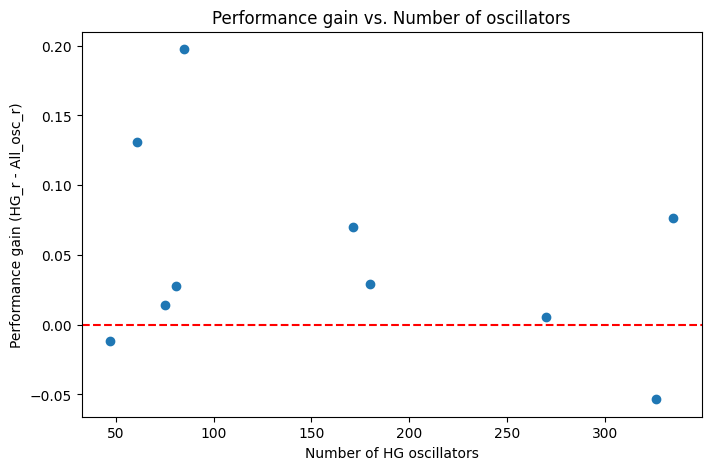

In [14]:
hg_oscs = np.array([335, 326, 171, 81, 75, 270, 180, 47, 61, 85])
#hg_oscs = np.array([826, 759, 534, 441, 224, 658, 503, 221, 489, 511])
all_osc_r = np.array([0.313524,0.511453,0.674847,0.694646,0.466138,0.809089,0.703751,0.582714,0.522065,0.514975])
hg_r = np.array([0.390181,0.458108,0.744658,0.722357,0.480513,0.814357,0.733188,0.570820,0.652857,0.712456])
broad_r = np.array([0.373689, 0.489390, 0.730746, 0.738738, 0.470855, 0.815877, 0.714142, 0.588065, 0.615503, 0.659110])
#diffs = hg_r-all_osc_r
diffs = np.array([0.0767, -0.0534, 0.0699, 0.0278, 0.0144, 0.0053, 0.0294, -0.0119, 0.1308, 0.1975])

print(np.mean(broad_r))
plt.figure(figsize=(8, 5))
plt.scatter(hg_oscs, diffs)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Number of HG oscillators')
plt.ylabel('Performance gain (HG_r - All_osc_r)')
plt.title('Performance gain vs. Number of oscillators')